In [2]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import json
from google.colab import drive
drive.mount('/content/drive/')
import os
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CS6540/' #
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

Mounted at /content/drive/
['gstorer-A1-MLP.ipynb', 'gstorer-A1-CNN.ipynb', 'content', 'gstorer-A3-RNN.ipynb', 'WildGraphBench', 'graph.gml', 'threshold_0_6.gml', 'threshold_0_7.gml', 'embeddings.pt', 'transfer_learning.ipynb', 'mcu-embeddings', 'train_embeddings.ipynb']


In [3]:
def build_training_pairs(questions, all_chunks, top_k=3):
    """
    For each question, retrieve top-k chunks as positives,
    and random distant chunks as negatives.
    """
    examples = []

    # Embed all chunks once
    chunk_embeddings = embed_model.encode(all_chunks, convert_to_tensor=True)

    for q in questions:
        q_emb = embed_model.encode(q, convert_to_tensor=True)

        # Cosine similarity to all chunks
        sims = util.cos_sim(q_emb, chunk_embeddings)[0]

        # Top-k = positives, bottom-k = hard negatives
        top_indices = sims.topk(top_k).indices.tolist()
        bottom_indices = sims.topk(top_k, largest=False).indices.tolist()

        for pos_idx in top_indices:
            for neg_idx in bottom_indices:
                examples.append(InputExample(
                    texts=[q, all_chunks[pos_idx], all_chunks[neg_idx]]
                ))

    return examples

In [4]:
REPO_PATH = '/content/drive/MyDrive/CS6540/WildGraphBench'
DOMAIN = 'culture'
PATH = path = f"{REPO_PATH}/QA/{DOMAIN}/questions.jsonl"

import glob
def load_questions(path):
    questions, gold_answers = [], []
    with open(path) as f:
        for line in f:
            item = json.loads(line)
            if "answer" not in item:
                continue  # skip malformed entries
            questions.append(item["question"])
            gold_answers.append(item["answer"])
    return questions, gold_answers


def load_reference_pages(domain, topic, chunk_size=300):
    folder = f"{REPO_PATH}/corpus/{domain}/{topic}/reference_pages/"
    all_chunks = []
    for filepath in glob.glob(folder + "*.txt"):
        with open(filepath, "r", errors="ignore") as f:
            text = f.read()
        words = text.split()
        for i in range(0, len(words), chunk_size):
            chunk = " ".join(words[i:i+chunk_size])
            node_id = f"{os.path.basename(filepath)}__{i}"
            all_chunks.append((node_id, chunk))
    return all_chunks

In [5]:
def get_positive_chunks(questions, gold_answers, all_chunks_with_ids, embed_model, top_k=3):
    """
    For each question, find the chunks most relevant to its gold answer.
    Returns a list of lists: retrieved_positives[i] = [chunk_text1, chunk_text2, ...] for questions[i]
    """
    from sentence_transformers import util

    all_chunk_texts = [chunk_tuple[1] for chunk_tuple in all_chunks_with_ids]
    chunk_embeddings = embed_model.encode(all_chunk_texts, convert_to_tensor=True)
    retrieved_positives = []

    for question, answer in zip(questions, gold_answers):
        # First try: find chunks that literally contain part of the answer
        answer_words = set(answer.lower().split())
        scored = []
        for chunk_text in all_chunk_texts:
            chunk_words = set(chunk_text.lower().split())
            overlap = len(answer_words & chunk_words) / max(len(answer_words), 1)
            scored.append(overlap)

        best_overlap = max(scored)

        if best_overlap > 0.3:
            # Use word overlap to find positives
            top_indices = sorted(range(len(scored)), key=lambda i: scored[i], reverse=True)[:top_k]
        else:
            # Fallback: embed the answer and find similar chunks
            answer_emb = embed_model.encode(answer, convert_to_tensor=True)
            sims = util.cos_sim(answer_emb, chunk_embeddings)[0]
            top_indices = sims.topk(top_k).indices.tolist()

        retrieved_positives.append([all_chunk_texts[i] for i in top_indices])

    return retrieved_positives

# Usage

questions, gold_answers = load_questions(PATH)
retrieved_positives = get_positive_chunks(questions, gold_answers, load_reference_pages("culture", 'Marvel Cinematic Universe', chunk_size=300), SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2'))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
from sentence_transformers import SentenceTransformer, losses, InputExample
from torch.utils.data import DataLoader

DOMAIN = "culture"

PATH = path = f"{REPO_PATH}/QA/{DOMAIN}/questions.jsonl"
TOPIC = 'Marvel Cinematic Universe'

questions, gold_answers = load_questions(PATH)
all_chunks = load_reference_pages(DOMAIN, TOPIC)


# Load the base model
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Build pairs — just (question, positive_chunk), no explicit negatives needed
# MNRL uses other items in the batch as negatives
simple_examples = []
for q, chunks in zip(questions, retrieved_positives):
    for chunk in chunks:
        simple_examples.append(InputExample(texts=[q, chunk]))

train_dataloader = DataLoader(simple_examples, shuffle=True, batch_size=16)

# MultipleNegativesRankingLoss is best for retrieval tasks
train_loss = losses.MultipleNegativesRankingLoss(embed_model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Mcu-eval Cosine Accuracy@1,Mcu-eval Cosine Accuracy@3,Mcu-eval Cosine Accuracy@5,Mcu-eval Cosine Accuracy@10,Mcu-eval Cosine Precision@1,Mcu-eval Cosine Precision@3,Mcu-eval Cosine Precision@5,Mcu-eval Cosine Recall@1,Mcu-eval Cosine Recall@3,Mcu-eval Cosine Recall@5,Mcu-eval Cosine Ndcg@10,Mcu-eval Cosine Mrr@10,Mcu-eval Cosine Map@100
24,No log,No log,0.308943,0.569106,0.650407,0.756098,0.308943,0.222222,0.165854,0.102981,0.222222,0.276423,0.321394,0.452333,0.237399
48,No log,No log,0.398374,0.682927,0.747967,0.821138,0.398374,0.271003,0.204878,0.132791,0.271003,0.341463,0.396863,0.544644,0.306134
72,No log,No log,0.471545,0.756098,0.821138,0.910569,0.471545,0.319783,0.261789,0.157182,0.319783,0.436314,0.476801,0.622238,0.381150
96,No log,No log,0.536585,0.788618,0.869919,0.959350,0.536585,0.357724,0.286179,0.178862,0.357724,0.476965,0.538547,0.678104,0.431519
120,No log,No log,0.528455,0.788618,0.869919,0.967480,0.528455,0.360434,0.289431,0.176152,0.360434,0.482385,0.547483,0.677020,0.440015


Epoch 1.0 | Avg Loss: 2.0416 | Eval Score: 0.3214


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1.0 | Avg Loss: 2.0416 | Eval Score: 0.3214
Epoch 2.0 | Avg Loss: 1.7760 | Eval Score: 0.3969


...

Epoch 3.0 | Avg Loss: 1.4323 | Eval Score: 0.4768
Epoch 4.0 | Avg Loss: 1.2013 | Eval Score: 0.5385


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 4.0 | Avg Loss: 1.2013 | Eval Score: 0.5385
Epoch 5.0 | Avg Loss: 1.0174 | Eval Score: 0.5475


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 5.0 | Avg Loss: 1.0174 | Eval Score: 0.5475


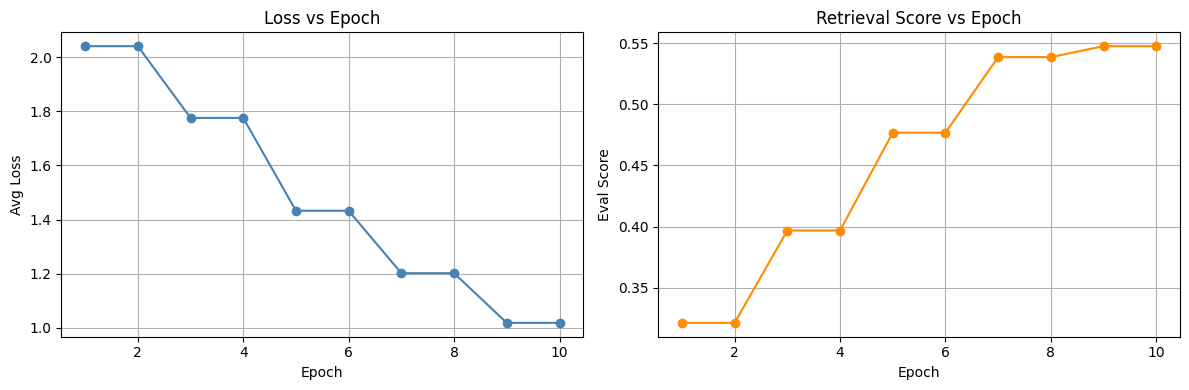

In [20]:
import matplotlib.pyplot as plt
import torch
import types
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# --- 1. Track loss by wrapping the loss function ---
batch_losses = []
epoch_losses = []
eval_scores = []  # <-- add this

_original_forward_fn = train_loss.__class__.forward

def tracked_forward(self, *args, **kwargs):
    loss = _original_forward_fn(self, *args, **kwargs)
    batch_losses.append(loss.item())
    return loss

train_loss.forward = types.MethodType(tracked_forward, train_loss)

# --- 2. Build an evaluator for accuracy (retrieval precision@k) ---
queries = {str(i): q for i, q in enumerate(questions)}
corpus = {str(i): chunk for i, chunk in enumerate([chunk for chunks in retrieved_positives for chunk in chunks])}

relevant_docs = {}
idx = 0
for i, pos_chunks in enumerate(retrieved_positives):
    relevant_docs[str(i)] = set()
    for chunk in pos_chunks:
        relevant_docs[str(i)].add(str(idx))
        idx += 1

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="mcu-eval",
    precision_recall_at_k=[1, 3, 5],
)

# --- 3. Callback to record epoch losses and eval scores ---
steps_per_epoch = len(train_dataloader)

def loss_callback(score, epoch, steps):
    start = int(epoch - 1) * steps_per_epoch
    end = int(epoch) * steps_per_epoch
    avg = sum(batch_losses[start:end]) / max(len(batch_losses[start:end]), 1)
    epoch_losses.append(avg)
    eval_scores.append(score)  # <-- collect directly from callback
    print(f"Epoch {epoch} | Avg Loss: {avg:.4f} | Eval Score: {score:.4f}")

# --- 4. Train ---
embed_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=5,
    warmup_steps=50,
    output_path="/content/drive/MyDrive/CS6540/mcu-embeddings",
    evaluator=evaluator,
    evaluation_steps=steps_per_epoch,
    callback=loss_callback,
    show_progress_bar=True,
)

# --- 5. Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(epoch_losses) + 1)

ax1.plot(epochs_range, epoch_losses, marker='o', color='steelblue')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Avg Loss")
ax1.set_title("Loss vs Epoch")
ax1.grid(True)

ax2.plot(range(1, len(eval_scores) + 1), eval_scores, marker='o', color='darkorange')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Eval Score")
ax2.set_title("Retrieval Score vs Epoch")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Measures how often the top-k most relevant chunks make it into the context we feed into the model.

In [21]:
from sentence_transformers import SentenceTransformer, losses, InputExample
from torch.utils.data import DataLoader

DOMAIN = "geography"

PATH = path = f"{REPO_PATH}/QA/{DOMAIN}/questions.jsonl"
TOPIC = 'United States'

questions, gold_answers = load_questions(PATH)
all_chunks = load_reference_pages(DOMAIN, TOPIC)


# Load the base model
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Build pairs — just (question, positive_chunk), no explicit negatives needed
# MNRL uses other items in the batch as negatives
simple_examples = []
for q, chunks in zip(questions, retrieved_positives):
    for chunk in chunks:
        simple_examples.append(InputExample(texts=[q, chunk]))

train_dataloader = DataLoader(simple_examples, shuffle=True, batch_size=16)

# MultipleNegativesRankingLoss is best for retrieval tasks
train_loss = losses.MultipleNegativesRankingLoss(embed_model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Mcu-eval Cosine Accuracy@1,Mcu-eval Cosine Accuracy@3,Mcu-eval Cosine Accuracy@5,Mcu-eval Cosine Accuracy@10,Mcu-eval Cosine Precision@1,Mcu-eval Cosine Precision@3,Mcu-eval Cosine Precision@5,Mcu-eval Cosine Recall@1,Mcu-eval Cosine Recall@3,Mcu-eval Cosine Recall@5,Mcu-eval Cosine Ndcg@10,Mcu-eval Cosine Mrr@10,Mcu-eval Cosine Map@100
13,No log,No log,0.015385,0.030769,0.061538,0.092308,0.015385,0.010256,0.012308,0.005128,0.010256,0.020513,0.021725,0.032692,0.018157
26,No log,No log,0.015385,0.061538,0.076923,0.107692,0.015385,0.020513,0.015385,0.005128,0.020513,0.025641,0.029400,0.042222,0.027687
39,No log,No log,0.046154,0.107692,0.169231,0.292308,0.046154,0.035897,0.036923,0.015385,0.035897,0.061538,0.078435,0.102735,0.058926
52,No log,No log,0.138462,0.246154,0.353846,0.584615,0.138462,0.097436,0.089231,0.046154,0.097436,0.148718,0.183031,0.245287,0.141295
65,No log,No log,0.246154,0.523077,0.646154,0.769231,0.246154,0.210256,0.166154,0.082051,0.210256,0.276923,0.321818,0.410440,0.242936
78,No log,No log,0.415385,0.646154,0.784615,0.876923,0.415385,0.292308,0.255385,0.138462,0.292308,0.425641,0.446265,0.555079,0.359765
91,No log,No log,0.476923,0.784615,0.846154,0.938462,0.476923,0.369231,0.292308,0.158974,0.369231,0.487179,0.532397,0.636600,0.430373
104,No log,No log,0.507692,0.830769,0.907692,0.969231,0.507692,0.410256,0.332308,0.169231,0.410256,0.553846,0.589261,0.678413,0.482220
117,No log,No log,0.553846,0.846154,0.938462,0.969231,0.553846,0.415385,0.350769,0.184615,0.415385,0.584615,0.613339,0.706068,0.505933
130,No log,No log,0.553846,0.861538,0.938462,0.984615,0.553846,0.420513,0.350769,0.184615,0.420513,0.584615,0.617715,0.708889,0.509952


Epoch 1.0 | Avg Loss: 3.2416 | Eval Score: 0.0217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1.0 | Avg Loss: 3.2416 | Eval Score: 0.0217
Epoch 2.0 | Avg Loss: 3.0592 | Eval Score: 0.0294


...

Epoch 8.0 | Avg Loss: 1.2640 | Eval Score: 0.5893
Epoch 9.0 | Avg Loss: 1.1778 | Eval Score: 0.6133


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9.0 | Avg Loss: 1.1778 | Eval Score: 0.6133
Epoch 10.0 | Avg Loss: 1.0603 | Eval Score: 0.6177


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 10.0 | Avg Loss: 1.0603 | Eval Score: 0.6177


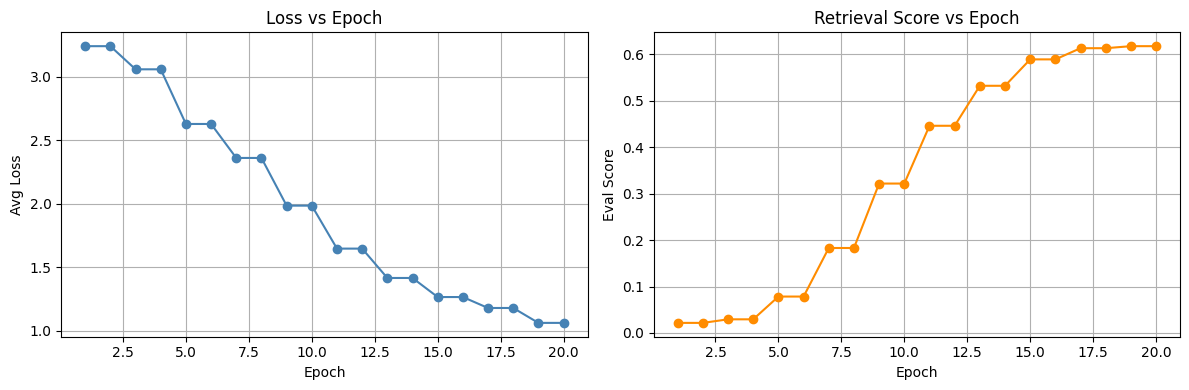

In [22]:
import matplotlib.pyplot as plt
import torch
import types
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# --- 1. Track loss by wrapping the loss function ---
batch_losses = []
epoch_losses = []
eval_scores = []  # <-- add this

_original_forward_fn = train_loss.__class__.forward

def tracked_forward(self, *args, **kwargs):
    loss = _original_forward_fn(self, *args, **kwargs)
    batch_losses.append(loss.item())
    return loss

train_loss.forward = types.MethodType(tracked_forward, train_loss)

# --- 2. Build an evaluator for accuracy (retrieval precision@k) ---
queries = {str(i): q for i, q in enumerate(questions)}
corpus = {str(i): chunk for i, chunk in enumerate([chunk for chunks in retrieved_positives for chunk in chunks])}

relevant_docs = {}
idx = 0
for i, pos_chunks in enumerate(retrieved_positives):
    relevant_docs[str(i)] = set()
    for chunk in pos_chunks:
        relevant_docs[str(i)].add(str(idx))
        idx += 1

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="mcu-eval",
    precision_recall_at_k=[1, 3, 5],
)

# --- 3. Callback to record epoch losses and eval scores ---
steps_per_epoch = len(train_dataloader)

def loss_callback(score, epoch, steps):
    start = int(epoch - 1) * steps_per_epoch
    end = int(epoch) * steps_per_epoch
    avg = sum(batch_losses[start:end]) / max(len(batch_losses[start:end]), 1)
    epoch_losses.append(avg)
    eval_scores.append(score)  # <-- collect directly from callback
    print(f"Epoch {epoch} | Avg Loss: {avg:.4f} | Eval Score: {score:.4f}")

# --- 4. Train ---
embed_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=10,
    warmup_steps=50,
    output_path="/content/drive/MyDrive/CS6540/mcu-embeddings",
    evaluator=evaluator,
    evaluation_steps=steps_per_epoch,
    callback=loss_callback,
    show_progress_bar=True,
)

# --- 5. Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(epoch_losses) + 1)

ax1.plot(epochs_range, epoch_losses, marker='o', color='steelblue')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Avg Loss")
ax1.set_title("Loss vs Epoch")
ax1.grid(True)

ax2.plot(range(1, len(eval_scores) + 1), eval_scores, marker='o', color='darkorange')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Eval Score")
ax2.set_title("Retrieval Score vs Epoch")
ax2.grid(True)

plt.tight_layout()
plt.show()